In [1]:
#演示：学习率衰减策略
#介绍：较之于adagrad,rmsprop,adam方式，我们可以使用等间隔，指定间隔，指数等方式，手动控制学习率的调整。

In [3]:
#等间隔学习率衰减
#关键参数：step_size:间隔批次：多少轮调整一次学习率   gamma:学习率衰减系数 lr 新 = lr旧*gamma
import torch
from torch import optim
import matplotlib.pyplot as plt

In [21]:
def dm01():
    #1、定义遍历，记录初始学习率,训练轮数，每轮训练的批次数
    lr,epoch,iteration = 0.1,200,10
    #2、创建数据集，y_true,x,w
    y_true = torch.tensor([0])
    X = torch.tensor(data=[1.0])
    w = torch.tensor(data = [1.0],requires_grad = True)  #权重参数，需要自动微分
    #3、创建优化器对象，动量法
    optimizer = optim.SGD(params = [w],lr = lr,momentum = 0.9)
    #4、创建学习率衰减对象
    #思路一：创建等间隔学习率衰减对象
    scheduler = optim.lr_scheduler.StepLR(optimizer,step_size = 50,gamma=0.5)
    #5、创建两个列表，分布表示训练轮数，每轮训练用的学习率。
    #epoch_list = [1,2,3,4,5,...]
    #lr_list = [0.1,0.1,0.1,....,0.05,0.05,....,0.025,0.025,....,0.0125,....]
    lr_list,epoch_list = [],[]
    #6、循环遍历训练
    for i in range(epoch):
        epoch_list.append(i+1)
        lr_list.append(scheduler.get_last_lr())   #获取最后的lr(learning_rate)

        #循环遍历，每轮每批次进行训练
        for batch in range(iteration):
            #先计算预测值，然后基于损失函数计算损失
            y_pred = w * X
            loss = (y_pred- y_true)**2
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        scheduler.step()
    print(epoch_list)
    print(f'lr_list:{lr_list}')
    plt.plot(epoch_list,lr_list)
    plt.xlabel('epoch')
    plt.ylabel('Learning Rate')
    plt.legend()
    plt.show()
    

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200]
lr_list:[[0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], 

C:\Users\lihuiting\AppData\Local\Temp\ipykernel_1288\1817366487.py:36: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


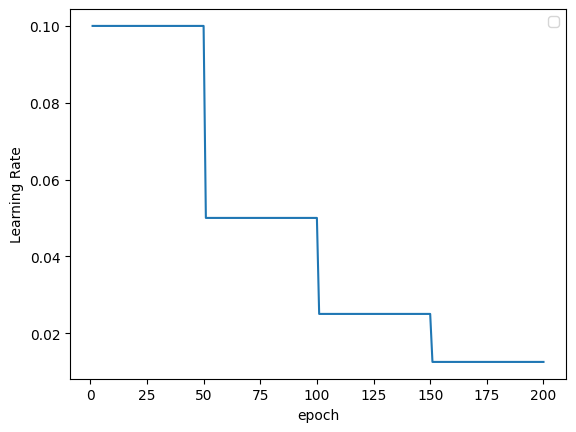

In [22]:
dm01()

In [23]:
def dm02():
    #1、定义遍历，记录初始学习率,训练轮数，每轮训练的批次数
    lr,epoch,iteration = 0.1,200,10
    #2、创建数据集，y_true,x,w
    y_true = torch.tensor([0])
    X = torch.tensor(data=[1.0])
    w = torch.tensor(data = [1.0],requires_grad = True)  #权重参数，需要自动微分
    #3、创建优化器对象，动量法
    optimizer = optim.SGD(params = [w],lr = lr,momentum = 0.9)
    #4、创建学习率衰减对象
    #定义变量：记录要修改学习率的轮数
    milestone = [50,125,160]
    #创建学习率衰减对象
    scheduler = optim.lr_scheduler.MultiStepLR(optimizer,milestones=milestone,gamma=0.5)
    #5、创建两个列表，分布表示训练轮数，每轮训练用的学习率。
    #epoch_list = [1,2,3,4,5,...]
    #lr_list = [0.1,0.1,0.1,....,0.05,0.05,....,0.025,0.025,....,0.0125,....]
    lr_list,epoch_list = [],[]
    #6、循环遍历训练
    for i in range(epoch):
        epoch_list.append(i+1)
        lr_list.append(scheduler.get_last_lr())   #获取最后的lr(learning_rate)

        #循环遍历，每轮每批次进行训练
        for batch in range(iteration):
            #先计算预测值，然后基于损失函数计算损失
            y_pred = w * X
            loss = (y_pred- y_true)**2
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        scheduler.step()
    print(epoch_list)
    print(f'lr_list:{lr_list}')
    plt.plot(epoch_list,lr_list)
    plt.xlabel('epoch')
    plt.ylabel('Learning Rate')
    plt.legend()
    plt.show()
    

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200]
lr_list:[[0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], 

C:\Users\lihuiting\AppData\Local\Temp\ipykernel_1288\3531602990.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


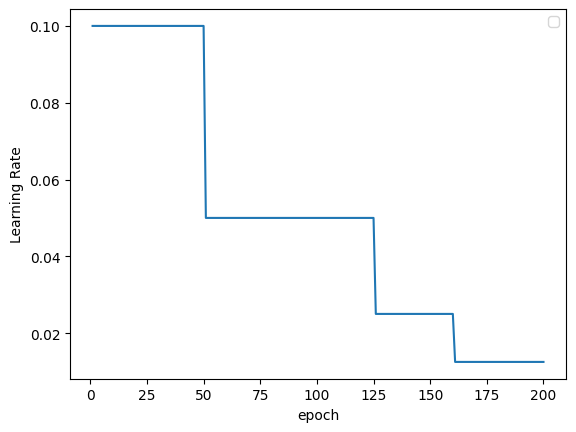

In [24]:
dm02()

In [27]:
def dm03():
    #1、定义遍历，记录初始学习率,训练轮数，每轮训练的批次数
    lr,epoch,iteration = 0.1,200,10
    #2、创建数据集，y_true,x,w
    y_true = torch.tensor([0])
    X = torch.tensor(data=[1.0])
    w = torch.tensor(data = [1.0],requires_grad = True)  #权重参数，需要自动微分
    #3、创建优化器对象，动量法
    optimizer = optim.SGD(params = [w],lr = lr,momentum = 0.9)
    #4、创建学习率衰减对象
    #创建学习率衰减对象
    scheduler = optim.lr_scheduler.ExponentialLR(optimizer,gamma=0.95)
    #5、创建两个列表，分布表示训练轮数，每轮训练用的学习率。
    #epoch_list = [1,2,3,4,5,...]
    #lr_list = [0.1,0.1,0.1,....,0.05,0.05,....,0.025,0.025,....,0.0125,....]
    lr_list,epoch_list = [],[]
    #6、循环遍历训练
    for i in range(epoch):
        epoch_list.append(i+1)
        lr_list.append(scheduler.get_last_lr())   #获取最后的lr(learning_rate)

        #循环遍历，每轮每批次进行训练
        for batch in range(iteration):
            #先计算预测值，然后基于损失函数计算损失
            y_pred = w * X
            loss = (y_pred- y_true)**2
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        scheduler.step()
    print(epoch_list)
    print(f'lr_list:{lr_list}')
    plt.plot(epoch_list,lr_list)
    plt.xlabel('epoch')
    plt.ylabel('Learning Rate')
    plt.legend()
    plt.show()
    

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200]
lr_list:[[0.1], [0.095], [0.09025], [0.0857375], [0.08145062499999998], [0.07737809374999999], [0.073509189

C:\Users\lihuiting\AppData\Local\Temp\ipykernel_1288\359990917.py:36: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


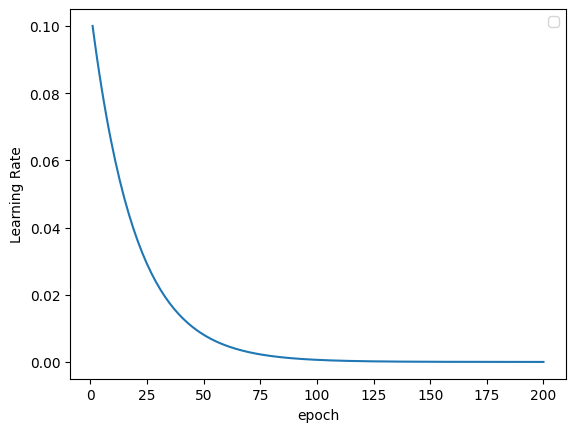

In [28]:
dm03()